In [1]:
import pm4py
import pandas as pd
import numpy as np
from pm4py.visualization.footprints import visualizer as fp_visualizer
from pm4py.algo.discovery.footprints import algorithm as footprints_discovery
from pm4py.algo.evaluation.replay_fitness import algorithm as replay_fitness_evaluator
from pm4py.algo.evaluation.precision import algorithm as precision_evaluator
from pm4py.algo.evaluation.simplicity import algorithm as simplicity_evaluator
from pm4py.algo.evaluation.generalization import algorithm as generalization_evaluator

In [2]:
log = pm4py.read_xes("../data/samples/clean_sample.xes.gz")

/Users/felixhauptmann/ProM-Assignment-Group-C/.venv/lib/python3.13/site-packages/pm4py/utils.py:1027: UserWarning: Install the optional requirement `r4pm` to import/export files faster. `rustxes` remains supported as a fallback.
  warnings.warn(


parsing log, completed traces ::   0%|          | 0/5000 [00:00<?, ?it/s]

In [3]:
log_noised = pm4py.read_xes("../data/samples/noised_sample.xes.gz")

parsing log, completed traces ::   0%|          | 0/5000 [00:00<?, ?it/s]

In [4]:
log_recovered = pm4py.read_xes("../data/samples/recovered_sample.xes.gz")

parsing log, completed traces ::   0%|          | 0/5000 [00:00<?, ?it/s]

In [5]:
df = pm4py.convert_to_dataframe(log)
df_noised = pm4py.convert_to_dataframe(log_noised)
df_recovered = pm4py.convert_to_dataframe(log_recovered)

In [6]:
dfg, start_activities, end_activities = pm4py.discover_dfg(log)
dfg_noised, start_activities_noised, end_activities_noised = pm4py.discover_dfg(log_noised)
dfg_recovered, start_activities_recovered, end_activities_recovered = pm4py.discover_dfg(log_recovered)

## a) Footprint Matrix

### 1. Clean log

In [7]:
footprints = footprints_discovery.apply(log)

In [8]:
footprints["sequence"]

{('A_Accepted', 'O_Create Offer'),
 ('A_Complete', 'A_Cancelled'),
 ('A_Complete', 'A_Denied'),
 ('A_Complete', 'O_Cancelled'),
 ('A_Complete', 'O_Create Offer'),
 ('A_Complete', 'O_Sent (mail and online)'),
 ('A_Complete', 'W_Shortened completion '),
 ('A_Concept', 'A_Accepted'),
 ('A_Concept', 'W_Shortened completion '),
 ('A_Create Application', 'A_Concept'),
 ('A_Create Application', 'A_Submitted'),
 ('A_Create Application', 'W_Complete application'),
 ('A_Denied', 'O_Refused'),
 ('A_Incomplete', 'O_Accepted'),
 ('A_Incomplete', 'O_Returned'),
 ('A_Pending', 'W_Call incomplete files'),
 ('A_Pending', 'W_Validate application'),
 ('A_Submitted', 'W_Handle leads'),
 ('A_Validating', 'A_Denied'),
 ('A_Validating', 'O_Accepted'),
 ('A_Validating', 'O_Returned'),
 ('O_Accepted', 'A_Pending'),
 ('O_Cancelled', 'A_Denied'),
 ('O_Cancelled', 'O_Create Offer'),
 ('O_Cancelled', 'O_Returned'),
 ('O_Created', 'A_Cancelled'),
 ('O_Created', 'A_Denied'),
 ('O_Created', 'O_Cancelled'),
 ('O_Creat

In [9]:
footprints["parallel"]

{('A_Accepted', 'W_Complete application'),
 ('A_Accepted', 'W_Shortened completion '),
 ('A_Cancelled', 'O_Cancelled'),
 ('A_Cancelled', 'W_Call after offers'),
 ('A_Cancelled', 'W_Call incomplete files'),
 ('A_Cancelled', 'W_Complete application'),
 ('A_Cancelled', 'W_Validate application'),
 ('A_Complete', 'W_Call after offers'),
 ('A_Concept', 'W_Complete application'),
 ('A_Denied', 'W_Call after offers'),
 ('A_Denied', 'W_Call incomplete files'),
 ('A_Denied', 'W_Complete application'),
 ('A_Denied', 'W_Validate application'),
 ('A_Incomplete', 'W_Call incomplete files'),
 ('A_Validating', 'W_Validate application'),
 ('O_Cancelled', 'A_Cancelled'),
 ('O_Cancelled', 'O_Cancelled'),
 ('O_Cancelled', 'O_Sent (mail and online)'),
 ('O_Cancelled', 'O_Sent (online only)'),
 ('O_Cancelled', 'W_Call after offers'),
 ('O_Cancelled', 'W_Call incomplete files'),
 ('O_Cancelled', 'W_Complete application'),
 ('O_Cancelled', 'W_Validate application'),
 ('O_Create Offer', 'O_Created'),
 ('O_Crea

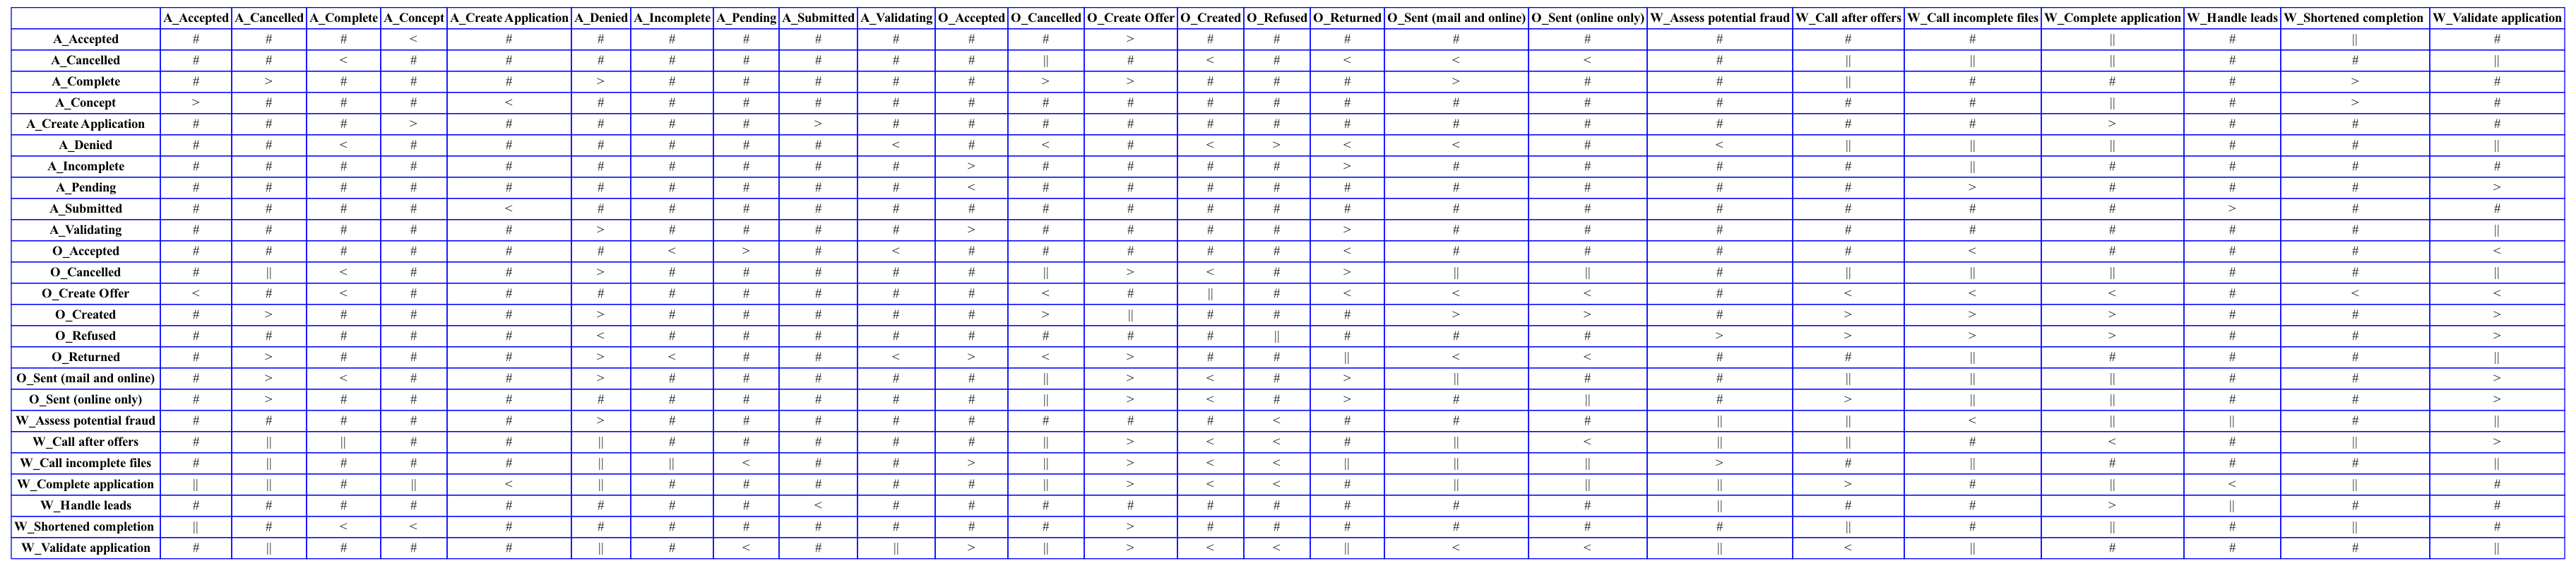

'../data/milestone2/footprints.svg'

In [10]:
gviz_footprints = fp_visualizer.apply(footprints)
fp_visualizer.view(gviz_footprints)
gviz_footprints.format = "svg"
gviz_footprints.render(
    filename="../data/milestone2/footprints",
    cleanup=True
)

#### Specific Trace

Confirms Footprint Matrix:

**Example for sequence (< / >):**

A_Create Application > A_Submitted

A_Submitted < A_Create Application

**Example for parallel (||):**

A_Complete || W_Call after offers

W_Call after offers || A_Complete

**Example for no relation (#):**

In [11]:
case_list = list(df['case:concept:name'].unique())

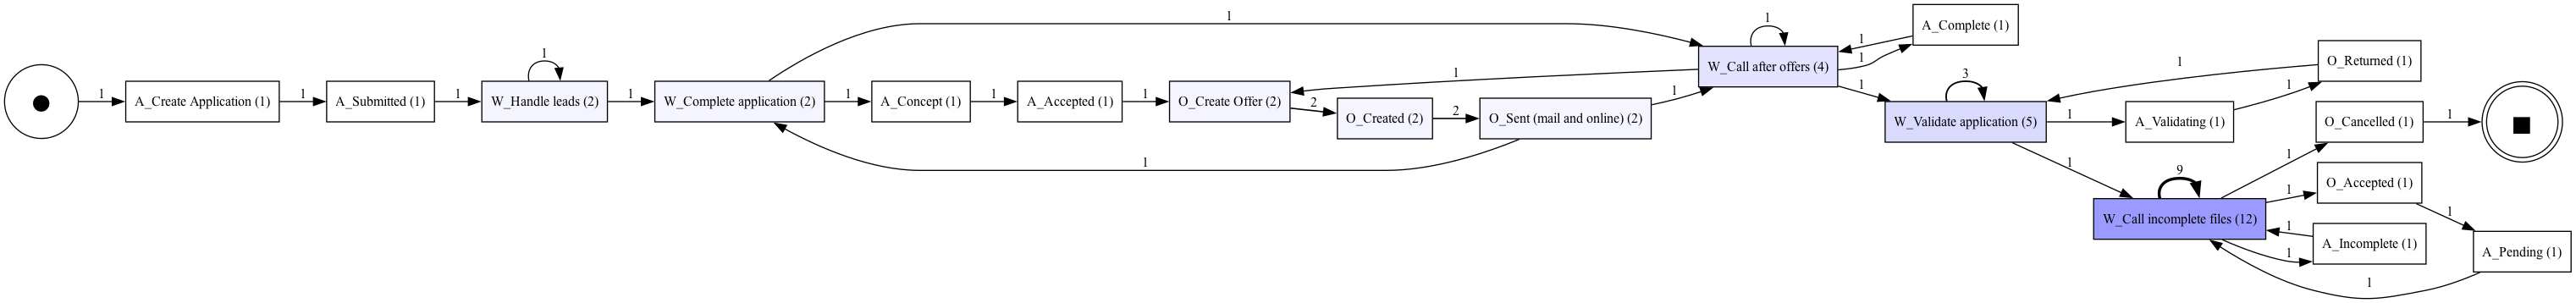

In [12]:
dfg_trace, start_activities_trace, end_activities_trace = pm4py.discover_dfg(df[df['case:concept:name'].isin(case_list[:1])])
pm4py.view_dfg(dfg_trace, start_activities_trace, end_activities_trace)

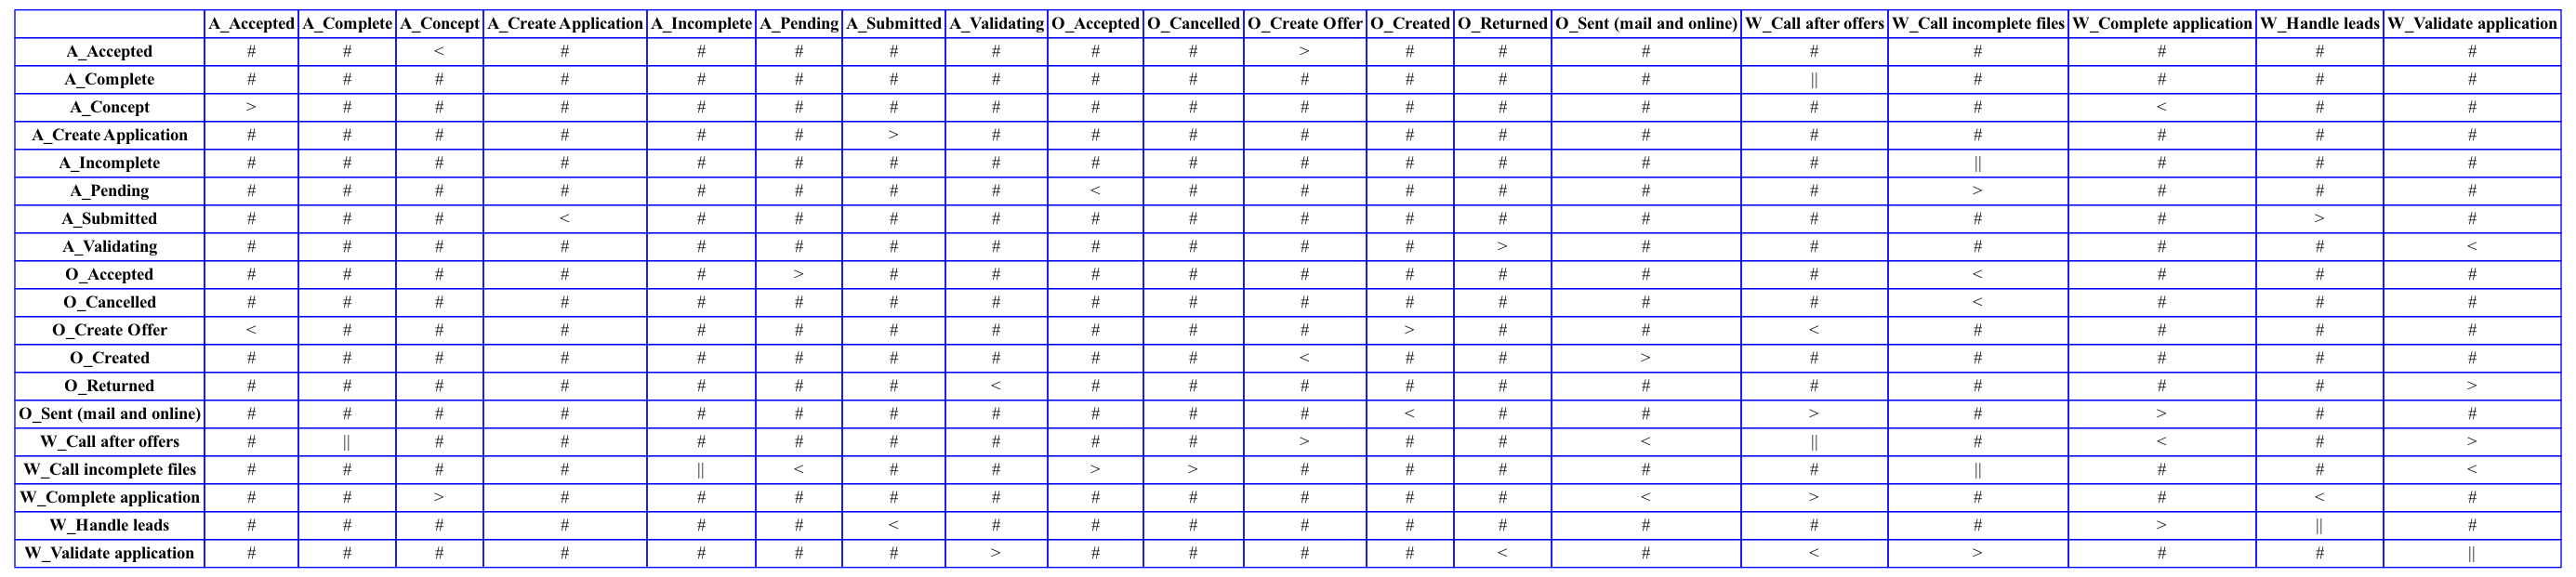

'../data/milestone2/footprints_trace.svg'

In [14]:
footprints_trace = footprints_discovery.apply(df[df['case:concept:name'].isin(case_list[:1])])
gviz_footprints_trace = fp_visualizer.apply(footprints_trace)
fp_visualizer.view(gviz_footprints_trace)
gviz_footprints_trace.format = "svg"
gviz_footprints_trace.render(
    filename="../data/milestone2/footprints_trace",
    cleanup=True
)

In [15]:
#('A_Create Application', 'A_Submitted') from sequence list
# Example for sequence (< / >):
print(dfg.get(("A_Create Application", "A_Submitted"), 0))
print(dfg.get(("A_Submitted", "A_Create Application"), 0))

3255
0


In [17]:
# ('A_Complete', 'W_Call after offers')
# Example for parallel (||):
print(dfg.get(("A_Complete", "W_Call after offers"), 0))
print(dfg.get(("W_Call after offers", "A_Complete"), 0))

4838
4979


In [18]:
# get activities from first trace

case_id = case_list[0]

trace_df = df[df["case:concept:name"] == case_id]

trace_activities = trace_df["concept:name"].tolist()

trace_activities

['A_Create Application',
 'A_Submitted',
 'W_Handle leads',
 'W_Handle leads',
 'W_Complete application',
 'A_Concept',
 'A_Accepted',
 'O_Create Offer',
 'O_Created',
 'O_Sent (mail and online)',
 'W_Complete application',
 'W_Call after offers',
 'W_Call after offers',
 'A_Complete',
 'W_Call after offers',
 'O_Create Offer',
 'O_Created',
 'O_Sent (mail and online)',
 'W_Call after offers',
 'W_Validate application',
 'W_Validate application',
 'A_Validating',
 'O_Returned',
 'W_Validate application',
 'W_Validate application',
 'W_Validate application',
 'W_Call incomplete files',
 'W_Call incomplete files',
 'A_Incomplete',
 'W_Call incomplete files',
 'W_Call incomplete files',
 'W_Call incomplete files',
 'W_Call incomplete files',
 'W_Call incomplete files',
 'W_Call incomplete files',
 'W_Call incomplete files',
 'W_Call incomplete files',
 'W_Call incomplete files',
 'O_Accepted',
 'A_Pending',
 'W_Call incomplete files',
 'O_Cancelled']

In [19]:
# find activities with no relation
def find_hash_relation_example(dfg, activities):
    for a in activities:
        for b in activities:
            if a == b:
                continue

            if dfg.get((a, b), 0) == 0 and dfg.get((b, a), 0) == 0:
                return a, b

    return None

In [20]:
find_hash_relation_example(dfg_trace, trace_activities)

('A_Create Application', 'W_Handle leads')

In [21]:
# Example for no relation:
print(dfg.get(("A_Create Application", "W_Handle leads"), 0))
print(dfg.get(("W_Handle leads", "A_Create Application"), 0))

0
0


### 2. Noised Log

In [22]:
footprints_noised = footprints_discovery.apply(log_noised)

In [23]:
footprints_noised["sequence"]

{('A_Acc.', 'O_Create Off.'),
 ('A_Acc.', 'O_Create Offer'),
 ('A_Acc. - Incident No. Application_435753618', 'O_Create Offer'),
 ('A_Acc. - Incident No. Application_562322973', 'O_Create Offer'),
 ('A_Accepted', 'O_Create Off.'),
 ('A_Accepted', 'O_Create Offer'),
 ('A_Accepted', 'O_Create Offer - Incident No. Application_1850936258'),
 ('A_Accepted', 'O_Create Offer - Incident No. Application_2066286284'),
 ('A_Accepted', 'O_Create Offer - Incident No. Application_342000872'),
 ('A_Accepted - Incident No. Application_1232536865', 'O_Create Offer'),
 ('A_Accepted - Incident No. Application_156712942', 'O_Create Offer'),
 ('A_Accepted - Incident No. Application_2055100599', 'O_Create Offer'),
 ('A_Accepted - Incident No. Application_54309881', 'O_Create Offer'),
 ('A_Canc.', 'O_Canc.'),
 ('A_Canc.', 'O_Cancelled'),
 ('A_Cancelled', 'O_Cancelled - Incident No. Application_147352520'),
 ('A_Cancelled', 'O_Cancelled - Incident No. Application_389383837'),
 ('A_Cancelled', 'O_Cancelled - I

In [24]:
footprints_noised["parallel"]

{('A_Acc.', 'W_Complete application'),
 ('A_Acc.', 'W_Finalize application'),
 ('A_Acc.', 'W_Finish application'),
 ('A_Accepted', 'W_Complete appl.'),
 ('A_Accepted', 'W_Complete application'),
 ('A_Accepted', 'W_Finalize application'),
 ('A_Accepted', 'W_Finish application'),
 ('A_Accepted', 'W_Shortened completion '),
 ('A_Cancelled', 'O_Canc.'),
 ('A_Cancelled', 'O_Cancelled'),
 ('A_Cancelled', 'W_Call after offers'),
 ('A_Cancelled', 'W_Call after ofrs.'),
 ('A_Cancelled', 'W_Call incomplete files'),
 ('A_Cancelled', 'W_Complete application'),
 ('A_Comp.', 'W_Call after offers'),
 ('A_Comp.', 'W_Call after ofrs.'),
 ('A_Complete', 'W_Call after offers'),
 ('A_Complete', 'W_Call after ofrs.'),
 ('A_Complete - Incident No. Application_1224580155', 'W_Call after offers'),
 ('A_Complete - Incident No. Application_1369571234', 'W_Call after offers'),
 ('A_Complete - Incident No. Application_1371149184', 'W_Call after offers'),
 ('A_Complete - Incident No. Application_1396568513', 'W_Ca

In [64]:
gviz_footprints_noised = fp_visualizer.apply(footprints_noised)
gviz_footprints_noised.format = "svg"
gviz_footprints_noised.render(
    filename="../data/milestone2/footprints_noised",
    cleanup=True
)

'../data/milestone2/footprints_noised.svg'

#### Specific Trace

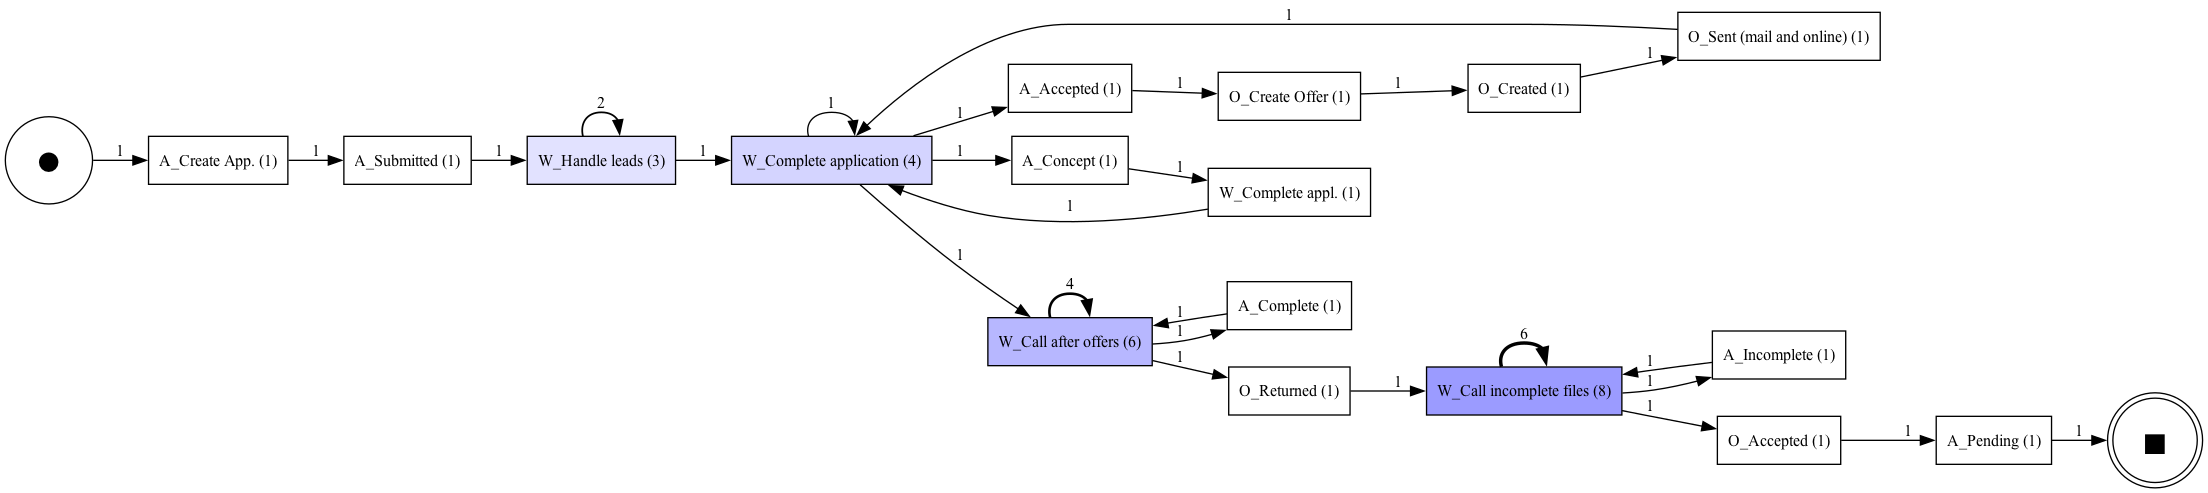

In [27]:
case_list_noised = list(df_noised['case:concept:name'].unique())

df_noised_trace = df_noised[
    df_noised['case:concept:name'].isin(case_list_noised[:1])
]

dfg_trace_noised, start_activities_trace_noised, end_activities_trace_noised = pm4py.discover_dfg(df_noised_trace)

pm4py.view_dfg(
    dfg_trace_noised,
    start_activities_trace_noised,
    end_activities_trace_noised
)

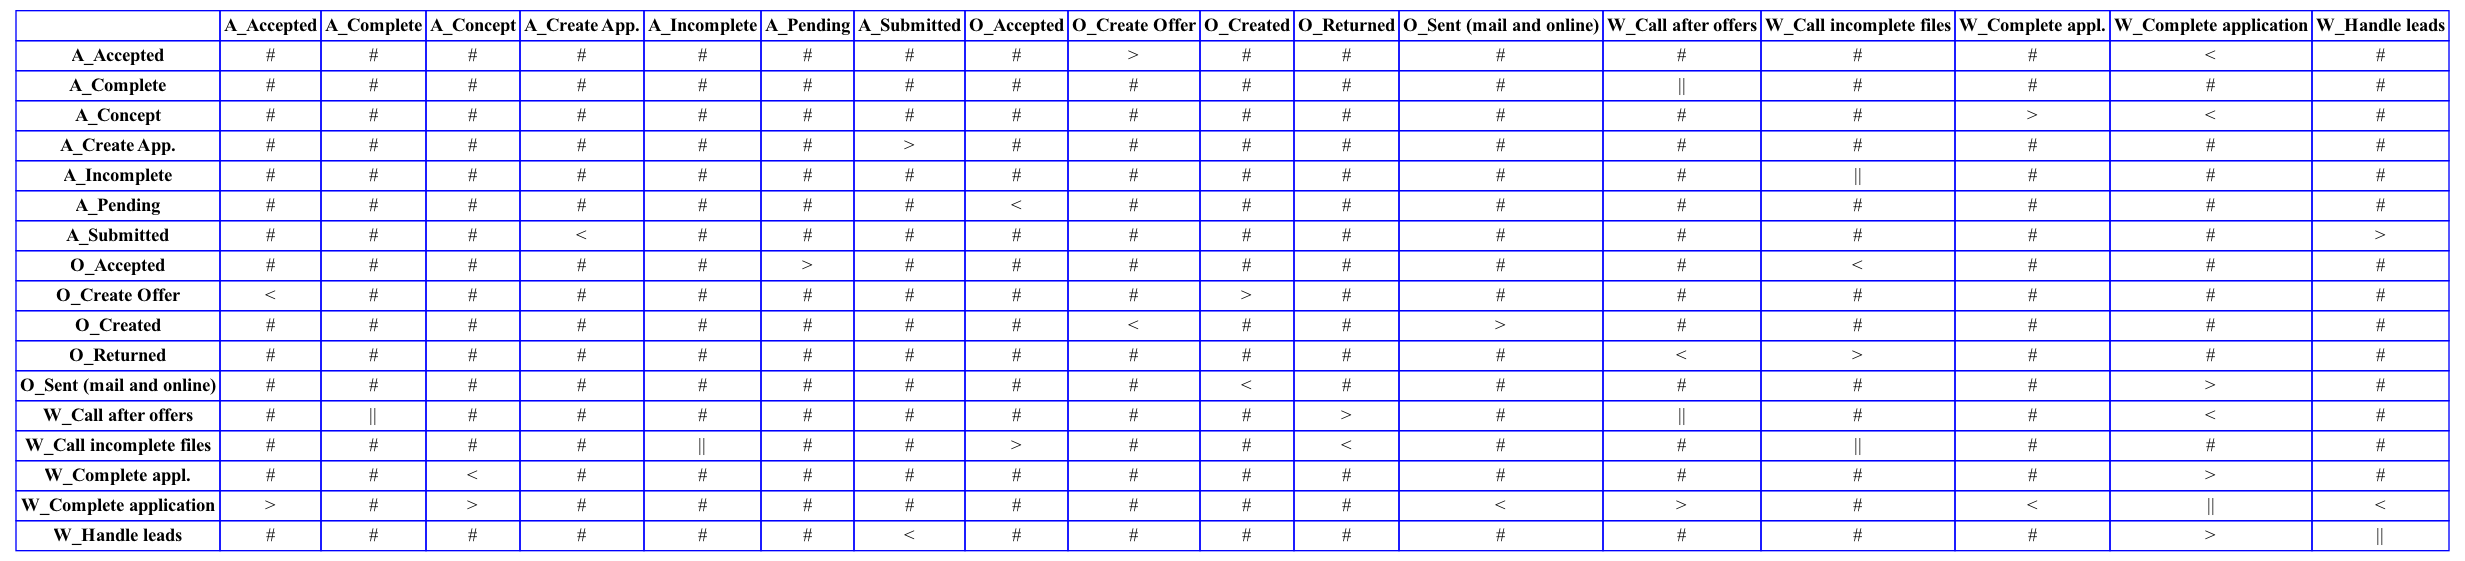

'../data/milestone2/footprints_trace_noised.svg'

In [40]:
df_noised_trace = df_noised[
    df_noised['case:concept:name'].isin(case_list_noised[:1])
]

footprints_trace_noised = footprints_discovery.apply(df_noised_trace)

gviz_footprints_trace_noised = fp_visualizer.apply(footprints_trace_noised)
fp_visualizer.view(gviz_footprints_trace_noised)

gviz_footprints_trace_noised.format = "svg"
gviz_footprints_trace_noised.render(
    filename="../data/milestone2/footprints_trace_noised",
    cleanup=True
)

In [34]:
#('A_Create Application', 'A_Submitted') from sequence list
# Example for sequence (< / >):
print(dfg_noised.get(("A_Create Application", "A_Submitted"), 0))
print(dfg_noised.get(("A_Submitted", "A_Create Application"), 0))

2923
0


In [35]:
# ('A_Complete', 'W_Call after offers')
# Example for parallel (||):
print(dfg_noised.get(("A_Complete", "W_Call after offers"), 0))
print(dfg_noised.get(("W_Call after offers", "A_Complete"), 0))

4383
4518


In [31]:
# get activities from first trace

case_id_noised = case_list_noised[0]

trace_df_noised = df_noised[df_noised["case:concept:name"] == case_id_noised]

trace_activities_noised = trace_df_noised["concept:name"].tolist()

trace_activities_noised

['A_Create App.',
 'A_Submitted',
 'W_Handle leads',
 'W_Handle leads',
 'W_Handle leads',
 'W_Complete application',
 'W_Complete application',
 'A_Concept',
 'W_Complete appl.',
 'W_Complete application',
 'A_Accepted',
 'O_Create Offer',
 'O_Created',
 'O_Sent (mail and online)',
 'W_Complete application',
 'W_Call after offers',
 'W_Call after offers',
 'A_Complete',
 'W_Call after offers',
 'W_Call after offers',
 'W_Call after offers',
 'W_Call after offers',
 'O_Returned',
 'W_Call incomplete files',
 'W_Call incomplete files',
 'A_Incomplete',
 'W_Call incomplete files',
 'W_Call incomplete files',
 'W_Call incomplete files',
 'W_Call incomplete files',
 'W_Call incomplete files',
 'W_Call incomplete files',
 'O_Accepted',
 'A_Pending']

In [32]:
find_hash_relation_example(dfg_trace_noised, trace_activities_noised)

('A_Create App.', 'W_Handle leads')

In [33]:
# Example for no relation:
print(dfg_noised.get(("A_Create Application", "W_Handle leads"),0))
print(dfg_noised.get(("W_Handle leads", "A_Create Application"),0))

0
0


### 3. Recovered Log

In [36]:
footprints_recovered = footprints_discovery.apply(log_recovered)

In [37]:
footprints_recovered["sequence"]

{('A_Accepted', 'O_Create Offer'),
 ('A_Concept', 'A_Accepted'),
 ('A_Create Application', 'A_Submitted'),
 ('A_Create Application', 'W_Complete application'),
 ('A_Denied', 'O_Refused'),
 ('A_Submitted', 'W_Handle leads'),
 ('A_Validating', 'A_Denied'),
 ('A_Validating', 'A_Incomplete'),
 ('A_Validating', 'A_Pending'),
 ('A_Validating', 'O_Returned'),
 ('O_Cancelled', 'A_Complete'),
 ('O_Cancelled', 'A_Denied'),
 ('O_Cancelled', 'A_Incomplete'),
 ('O_Cancelled', 'O_Create Offer'),
 ('O_Cancelled', 'O_Returned'),
 ('O_Created', 'A_Cancelled'),
 ('O_Created', 'A_Complete'),
 ('O_Created', 'A_Denied'),
 ('O_Created', 'A_Incomplete'),
 ('O_Created', 'O_Cancelled'),
 ('O_Created', 'O_Sent (mail and online)'),
 ('O_Created', 'O_Sent (online only)'),
 ('O_Created', 'W_Call after offers'),
 ('O_Created', 'W_Call incomplete files'),
 ('O_Created', 'W_Complete application'),
 ('O_Refused', 'W_Assess potential fraud'),
 ('O_Refused', 'W_Call after offers'),
 ('O_Refused', 'W_Call incomplete file

In [38]:
footprints_recovered["parallel"]

{('A_Accepted', 'W_Complete application'),
 ('A_Accepted', 'W_Shortened completion'),
 ('A_Cancelled', 'O_Cancelled'),
 ('A_Cancelled', 'W_Call after offers'),
 ('A_Cancelled', 'W_Call incomplete files'),
 ('A_Cancelled', 'W_Complete application'),
 ('A_Cancelled', 'W_Validate application'),
 ('A_Complete', 'O_Sent (mail and online)'),
 ('A_Complete', 'O_Sent (online only)'),
 ('A_Complete', 'W_Call after offers'),
 ('A_Complete', 'W_Complete application'),
 ('A_Concept', 'A_Create Application'),
 ('A_Concept', 'W_Complete application'),
 ('A_Concept', 'W_Handle leads'),
 ('A_Create Application', 'A_Concept'),
 ('A_Denied', 'W_Call after offers'),
 ('A_Denied', 'W_Call incomplete files'),
 ('A_Denied', 'W_Complete application'),
 ('A_Denied', 'W_Validate application'),
 ('A_Incomplete', 'O_Returned'),
 ('A_Incomplete', 'W_Call incomplete files'),
 ('A_Incomplete', 'W_Validate application'),
 ('A_Pending', 'O_Accepted'),
 ('A_Pending', 'W_Call incomplete files'),
 ('A_Pending', 'W_Valid

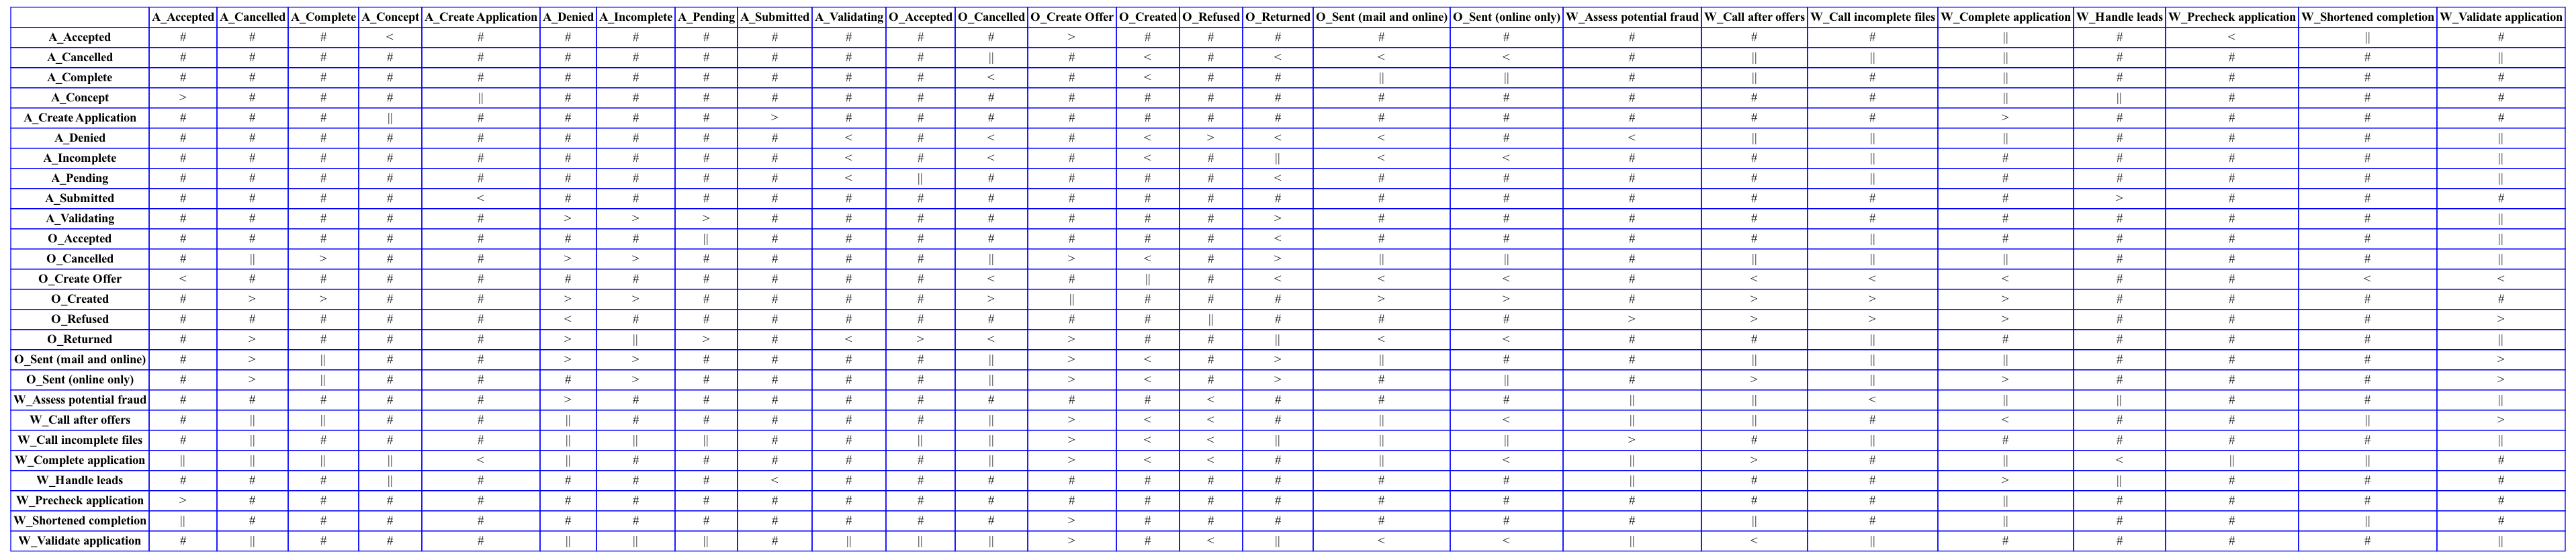

'../data/milestone2/footprints_recovered2.svg'

In [63]:
gviz_footprints_recovered = fp_visualizer.apply(footprints_recovered)
fp_visualizer.view(gviz_footprints_recovered)
gviz_footprints_recovered.format = "svg"
(gviz_footprints_recovered.render(
    filename="../data/milestone2/footprints_recovered",
    cleanup=True
))

#### Specific Trace

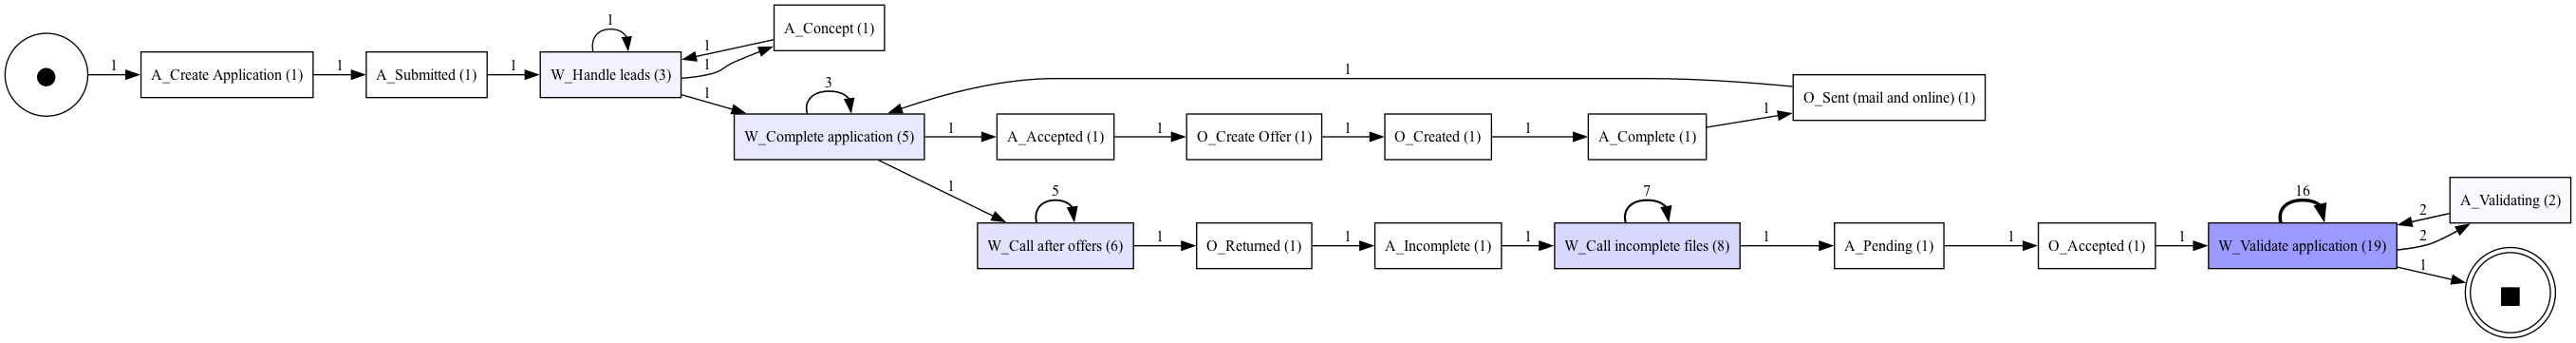

In [42]:
case_list_recovered = list(df_recovered['case:concept:name'].unique())

df_recovered_trace = df_recovered[
    df_recovered['case:concept:name'].isin(case_list_recovered[:1])
]

dfg_trace_recovered, start_activities_trace_recovered, end_activities_trace_recovered = pm4py.discover_dfg(df_recovered_trace)

pm4py.view_dfg(
    dfg_trace_recovered,
    start_activities_trace_recovered,
    end_activities_trace_recovered
)

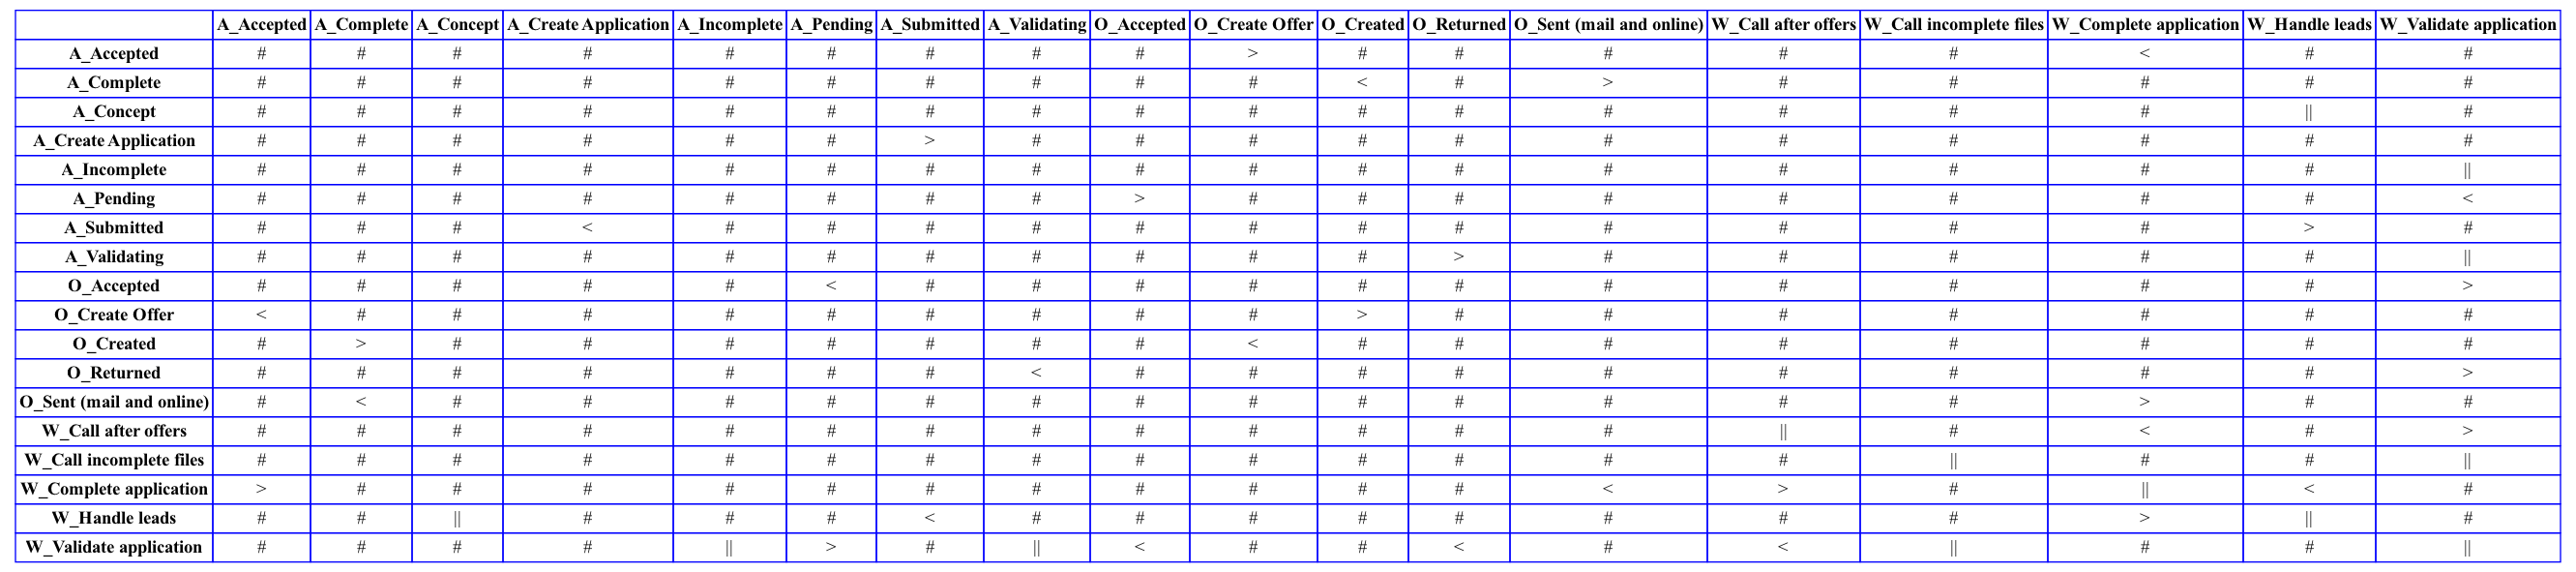

'../data/milestone2/footprints_trace_recovered.svg'

In [65]:
df_recovered_trace = df_recovered[
    df_recovered['case:concept:name'].isin(case_list_recovered[:1])
]

footprints_trace_recovered = footprints_discovery.apply(df_recovered_trace)

gviz_footprints_trace_recovered = fp_visualizer.apply(footprints_trace_recovered)
fp_visualizer.view(gviz_footprints_trace_recovered)
gviz_footprints_trace_recovered.format = "svg"
gviz_footprints_trace_recovered.render(
    filename="../data/milestone2/footprints_trace_recovered",
    cleanup=True
)

In [44]:
#('A_Create Application', 'A_Submitted') from sequence list
# Example for sequence (< / >):
print(dfg_recovered.get(("A_Create Application", "A_Submitted"), 0))
print(dfg_recovered.get(("A_Submitted", "A_Create Application"), 0))

3255
0


In [48]:
# ('A_Complete', 'W_Call after offers')
# Example for parallel (||):
print(dfg_recovered.get(("A_Concept", "W_Handle leads"), 0))
print(dfg_recovered.get(("W_Handle leads", "A_Concept"), 0))

3186
3227


In [49]:
# get activities from first trace

case_id_recovered = case_list_recovered[0]

trace_df_recovered = df_recovered[df_recovered["case:concept:name"] == case_id_recovered]

trace_activities_recovered = trace_df_recovered["concept:name"].tolist()

trace_activities_recovered

['A_Create Application',
 'A_Submitted',
 'W_Handle leads',
 'W_Handle leads',
 'A_Concept',
 'W_Handle leads',
 'W_Complete application',
 'W_Complete application',
 'W_Complete application',
 'W_Complete application',
 'A_Accepted',
 'O_Create Offer',
 'O_Created',
 'A_Complete',
 'O_Sent (mail and online)',
 'W_Complete application',
 'W_Call after offers',
 'W_Call after offers',
 'W_Call after offers',
 'W_Call after offers',
 'W_Call after offers',
 'W_Call after offers',
 'W_Validate application',
 'W_Validate application',
 'A_Validating',
 'O_Returned',
 'W_Validate application',
 'W_Validate application',
 'W_Validate application',
 'W_Validate application',
 'W_Validate application',
 'W_Validate application',
 'W_Validate application',
 'W_Validate application',
 'W_Validate application',
 'W_Validate application',
 'W_Validate application',
 'W_Validate application',
 'A_Incomplete',
 'W_Validate application',
 'W_Call incomplete files',
 'W_Call incomplete files',
 'W_Cal

In [50]:
find_hash_relation_example(dfg_trace_recovered, trace_activities_recovered)

('A_Create Application', 'W_Handle leads')

In [51]:
# Example for no relation:
print(dfg_recovered.get(("A_Create Application", "W_Handle leads"),0))
print(dfg_recovered.get(("W_Handle leads", "A_Create Application"),0))

0
0


## b) alpha-miner

In [52]:
from pm4py.algo.discovery.alpha import algorithm as alpha_miner
from pm4py.visualization.petri_net import visualizer as pn_visualizer

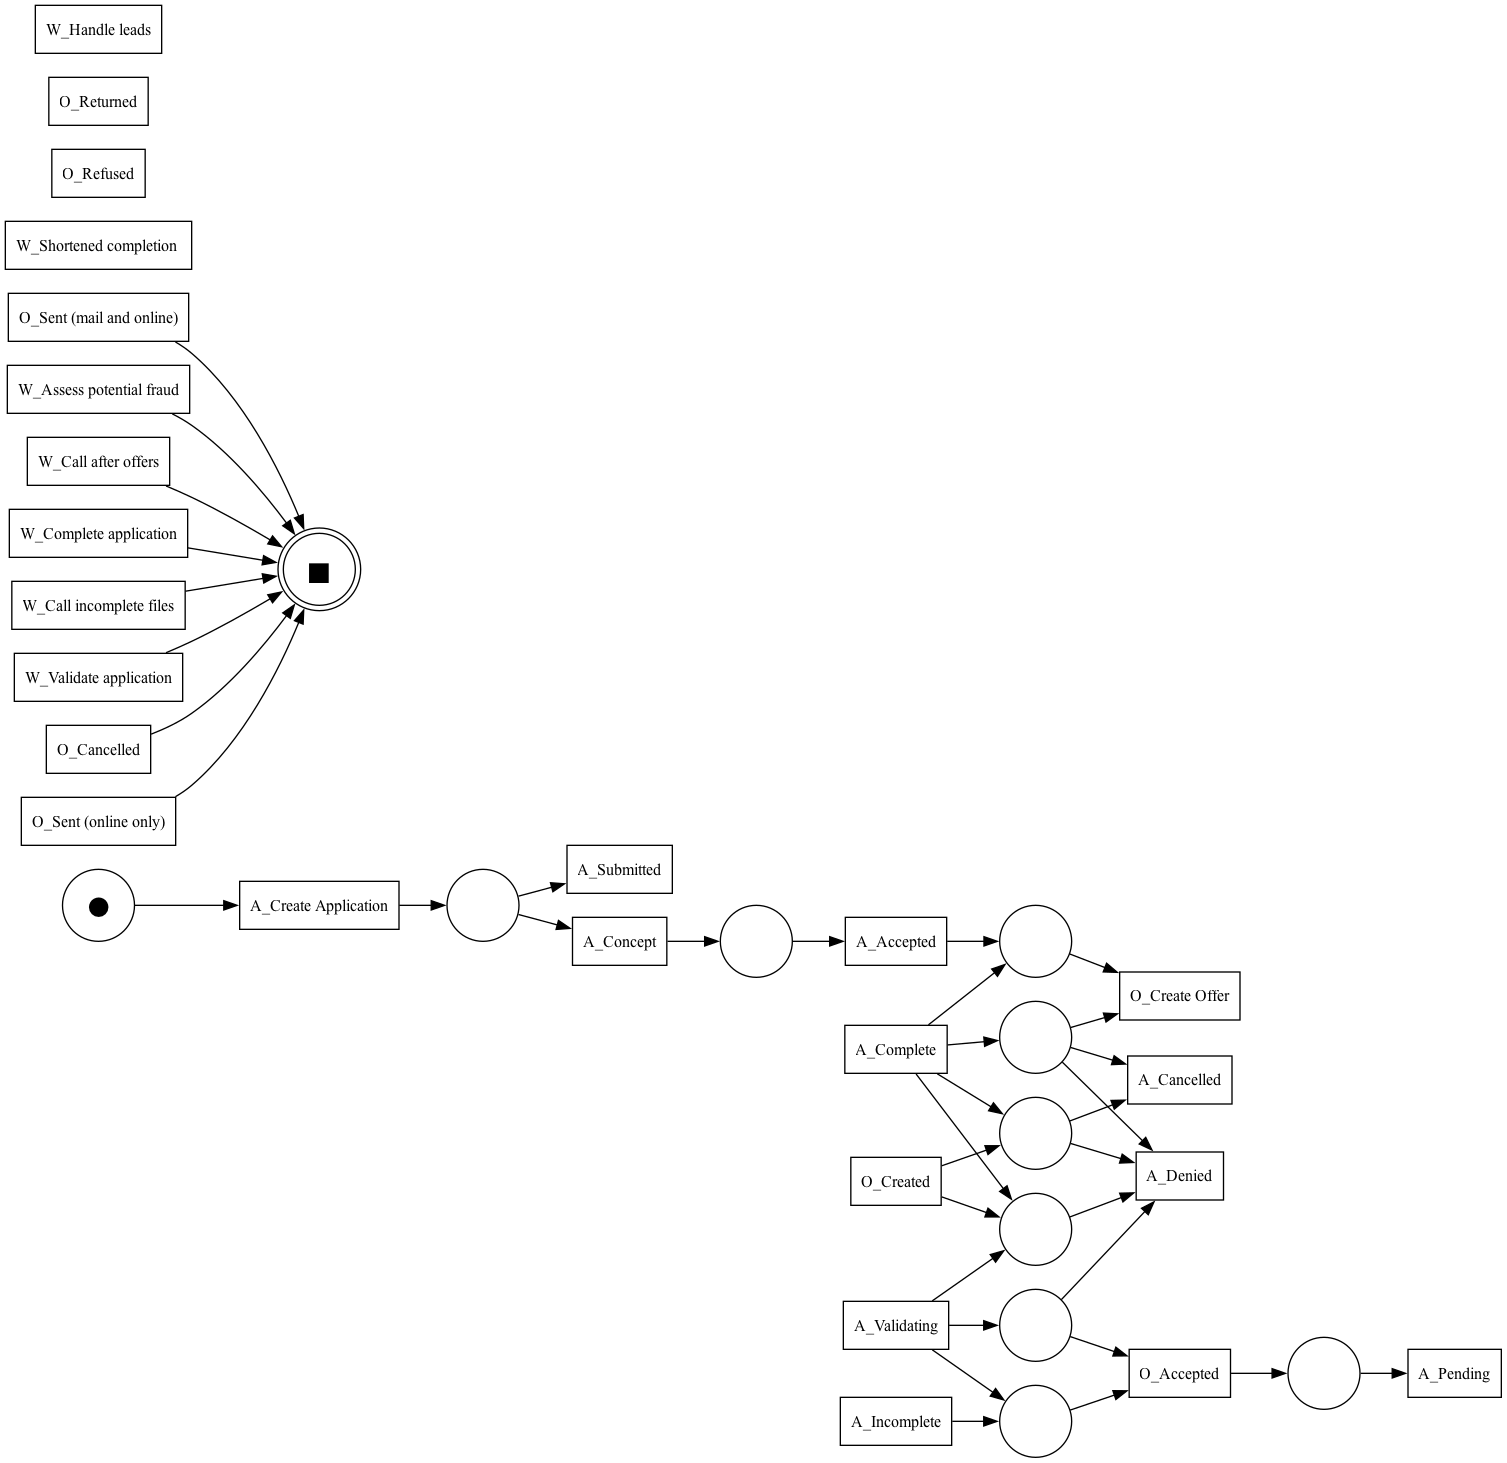

'../data/milestone2/petri_net_clean.svg'

In [53]:
net_clean, initial_marking_clean, final_marking_clean = alpha_miner.apply(log)

gviz_net_clean = pn_visualizer.apply(
    net_clean,
    initial_marking_clean,
    final_marking_clean
)

pn_visualizer.view(gviz_net_clean)

gviz_net_clean.format = "svg"
gviz_net_clean.render(
    filename="../data/milestone2/petri_net_clean",
    cleanup=True
)

In [54]:
net_noised, initial_marking_noised, final_marking_noised = alpha_miner.apply(df_noised)

gviz_net_noised = pn_visualizer.apply(
    net_noised,
    initial_marking_noised,
    final_marking_noised
)

pn_visualizer.view(gviz_net_noised)

gviz_net_noised.format = "svg"
gviz_net_noised.render(
    filename="../data/milestone2/petri_net_noised",
    cleanup=True
)

'../data/milestone2/petri_net_noised.svg'

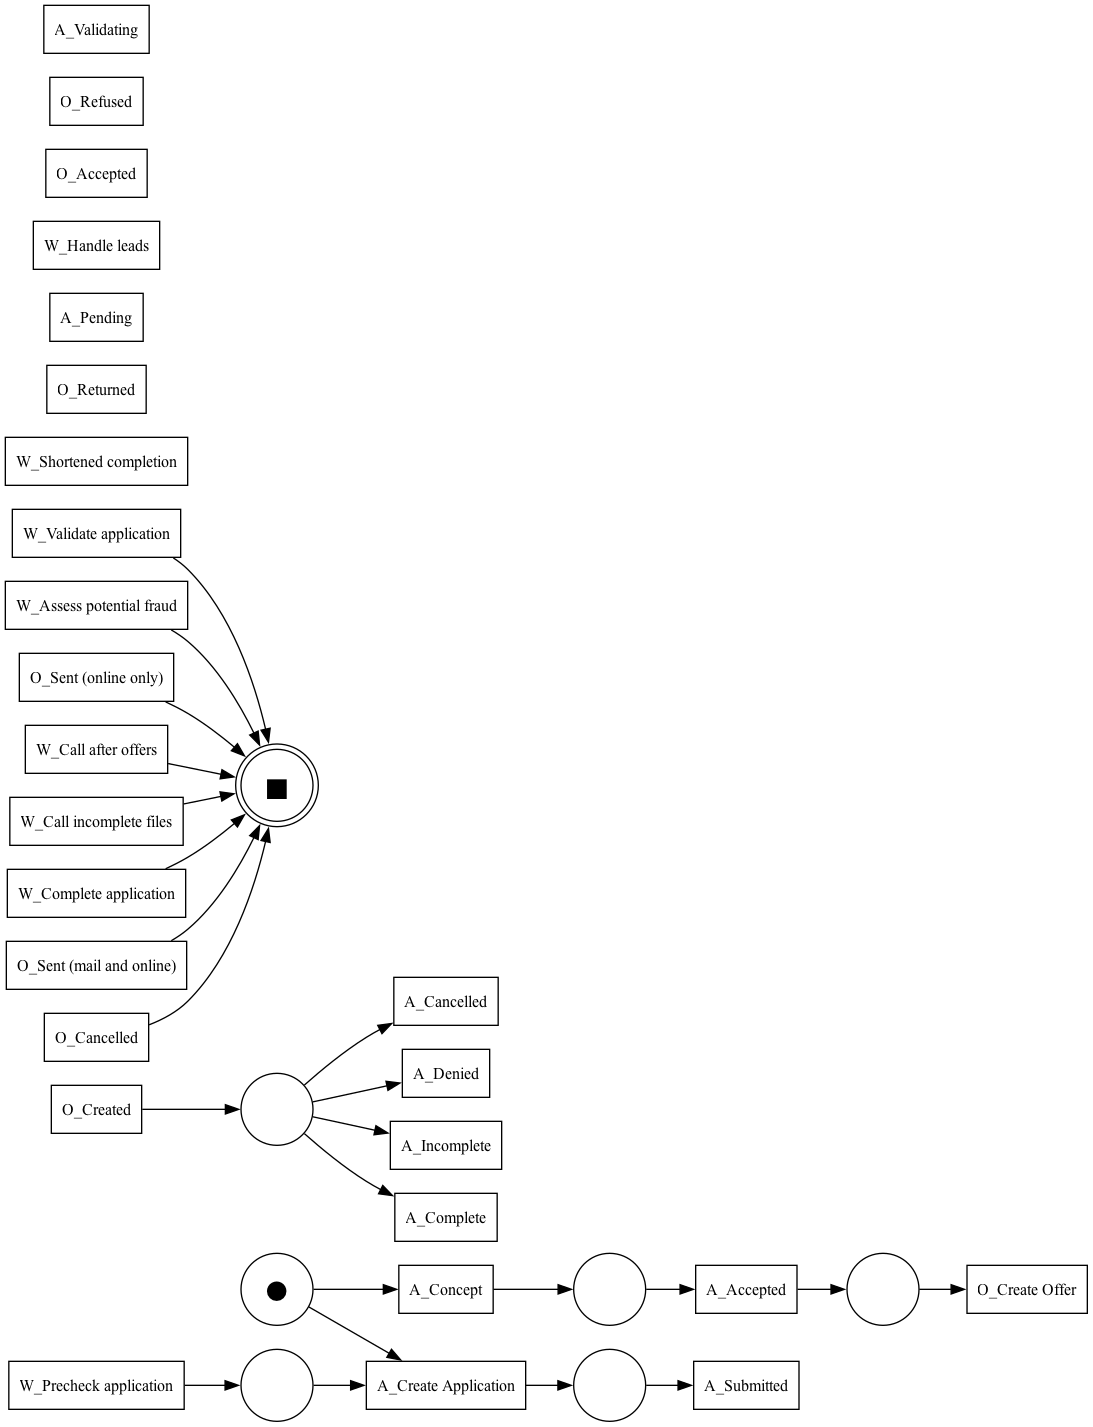

'../data/milestone2/petri_net_recovered.svg'

In [55]:
net_recovered, initial_marking_recovered, final_marking_recovered = alpha_miner.apply(log_recovered)

gviz_net_recovered = pn_visualizer.apply(
    net_recovered,
    initial_marking_recovered,
    final_marking_recovered
)

pn_visualizer.view(gviz_net_recovered)

gviz_net_recovered.format = "svg"
gviz_net_recovered.render(
    filename="../data/milestone2/petri_net_recovered",
    cleanup=True
)

In [56]:
print("Clean sample cases:", df["case:concept:name"].nunique())
print("Noised sample cases:", df_noised["case:concept:name"].nunique())
print("Recovered sample cases:", df_recovered["case:concept:name"].nunique())

print("Clean activities:", df["concept:name"].nunique())
print("Noised activities:", df_noised["concept:name"].nunique())
print("Recovered activities:", df_recovered["concept:name"].nunique())

Clean sample cases: 5000
Noised sample cases: 5000
Recovered sample cases: 5000
Clean activities: 25
Noised activities: 202
Recovered activities: 26


In [57]:
def evaluate_model(log, net, initial_marking, final_marking, name):
    fitness = replay_fitness_evaluator.apply(
        log,
        net,
        initial_marking,
        final_marking,
        variant=replay_fitness_evaluator.Variants.TOKEN_BASED
    )

    precision = precision_evaluator.apply(
        log,
        net,
        initial_marking,
        final_marking
    )

    generalization = generalization_evaluator.apply(
        log,
        net,
        initial_marking,
        final_marking
    )

    simplicity = simplicity_evaluator.apply(net)

    return {
        "model": name,
        "fitness": fitness,
        "precision": precision,
        "generalization": generalization,
        "simplicity": simplicity,
        "places": len(net.places),
        "transitions": len(net.transitions),
        "arcs": len(net.arcs)
    }

In [58]:
results = [
    evaluate_model(
        df,
        net_clean,
        initial_marking_clean,
        final_marking_clean,
        "Clean"
    ),
    evaluate_model(
        df_noised,
        net_noised,
        initial_marking_noised,
        final_marking_noised,
        "Noised"
    ),
    evaluate_model(
        df_recovered,
        net_recovered,
        initial_marking_recovered,
        final_marking_recovered,
        "Recovered"
    )
]

results

replaying log with TBR, completed traces ::   0%|          | 0/3132 [00:00<?, ?it/s]

computing precision with alignments, completed variants ::   0%|          | 0/54971 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/3132 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/4745 [00:00<?, ?it/s]

computing precision with alignments, completed variants ::   0%|          | 0/85263 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/4745 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/3207 [00:00<?, ?it/s]

computing precision with alignments, completed variants ::   0%|          | 0/57491 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/3207 [00:00<?, ?it/s]

[{'model': 'Clean',
  'fitness': {'perc_fit_traces': 0.0,
   'average_trace_fitness': 0.5164137321376121,
   'log_fitness': 0.497582690712434,
   'percentage_of_fitting_traces': 0.0},
  'precision': 0.0951859702668637,
  'generalization': 0.9755167412328847,
  'simplicity': 0.9473684210526317,
  'places': 11,
  'transitions': 25,
  'arcs': 37},
 {'model': 'Noised',
  'fitness': {'perc_fit_traces': 0.0,
   'average_trace_fitness': 0.4437569130123327,
   'log_fitness': 0.4322555062616288,
   'percentage_of_fitting_traces': 0.0},
  'precision': 0.0706910829829216,
  'generalization': 0.22553762597577065,
  'simplicity': 0.8546712802768166,
  'places': 45,
  'transitions': 202,
  'arcs': 268},
 {'model': 'Recovered',
  'fitness': {'perc_fit_traces': 0.0,
   'average_trace_fitness': 0.43820969533508203,
   'log_fitness': 0.41914154640514256,
   'percentage_of_fitting_traces': 0.0},
  'precision': 0.05554444666622227,
  'generalization': 0.9542526254474035,
  'simplicity': 1.0,
  'places': 7

In [59]:
print("Clean DFG edges:", len(dfg))
print("Recovered DFG edges:", len(dfg_recovered))

Clean DFG edges: 149
Recovered DFG edges: 158


### Explanation of results

In [61]:
print("Clean sequence:", len(footprints["sequence"]))
print("Noised sequence:", len(footprints_noised["sequence"]))
print("Recovered sequence:", len(footprints_recovered["sequence"]))

print("Clean parallel:", len(footprints["parallel"]))
print("Noised parallel:", len(footprints_noised["parallel"]))
print("Recovered parallel:", len(footprints_recovered["parallel"]))

Clean sequence: 65
Noised sequence: 439
Recovered sequence: 59
Clean parallel: 84
Noised parallel: 254
Recovered parallel: 108


In [60]:
clean_seq = footprints["sequence"]
noised_seq = footprints_noised["sequence"]
recovered_seq = footprints_recovered["sequence"]

clean_par = footprints["parallel"]
noised_par = footprints_noised["parallel"]
recovered_par = footprints_recovered["parallel"]

print("Noised added sequence relations:")
print(list(noised_seq - clean_seq)[:20])

print("Recovered removed noised sequence relations:")
print(list(noised_seq - recovered_seq)[:20])

print("Recovered missing clean sequence relations:")
print(list(clean_seq - recovered_seq)[:20])

print("Noised added parallel relations:")
print(list(noised_par - clean_par)[:20])

print("Recovered added parallel relations:")
print(list(recovered_par - clean_par)[:20])

Noised added sequence relations:
[('W_Call incomplete files', 'W_Call incomplete files - Incident No. Application_886146031'), ('W_Finalize application', 'W_Call after offers'), ('A_Create Application - Incident No. Application_1164942045', 'A_Submitted'), ('O_Created', 'W_Finalize application'), ('O_Ret.', 'A_Den.'), ('O_Sent (onl. only)', 'W_Call after offers'), ('A_Incomplete', 'W_Call incomplete files - Incident No. Application_1607880476'), ('O_Create Offer', 'O_Created - Incident No. Application_447178454'), ('O_Returned', 'W_Call incomplete files - Incident No. Application_1622587636'), ('O_Sent (mail and online)', 'A_Canc.'), ('W_Complete application - Incident No. Application_1995862436', 'W_Call after offers'), ('W_Precheck application: Credit History', 'W_Complete application'), ('A_Create Application', 'A_Subm.'), ('A_Create App.', 'W_Complete appl.'), ('O_Crtd.', 'W_Call incomplete files'), ('W_Complete application', 'W_Call after offers - Incident No. Application_12353758

The evaluation shows that the noised log strongly distorts the ﷿﷿-Miner result. Compared to the clean model, the noised model becomes much larger: the number of transitions increases from 25 to 202, the number of places from 11 to 45, and the number of arcs from 37 to 268. This is caused by polluted and distorted activity labels, for example shortened labels such as "A_Acc." or "W_Handle lds.", or activity names extended with "Incident No. Application". In the footprint matrix, these artificial labels create additional sequence and parallel relations. Since the ﷿﷿-Algorithm treats every distinct label as a separate activity and does not filter infrequent behavior, these artificial footprint cells are directly reflected in the mined Petri net. This explains the decrease in precision from 0.095 to 0.071 and especially the strong decrease in generalization from 0.976 to 0.226.

The recovered log removes many of these artificial variants. This is visible in the number of transitions, which decreases from 202 in the noised model to 26 in the recovered model, close to the 25 transitions of the clean model. Consequently, generalization improves strongly from 0.226 to 0.954, almost reaching the clean model's value of 0.976. This suggests that the recovery step successfully normalizes many polluted and distorted activity labels.

However, the recovered model is not identical to the clean model. Although the number of transitions is almost restored, the recovered model has fewer places and arcs than the clean model: 7 places and 23 arcs compared to 11 places and 37 arcs in the clean model. This indicates that the recovered footprint matrix does not fully reconstruct the original causal structure. Some relations that were clear sequence relations in the clean footprint may be missing, changed into parallel relations, or interpreted as choice relations after recovery.

This also explains why the recovered model is structurally simpler but not necessarily better in all quality dimensions. The ﷿﷿-Miner does not translate DFG edges directly into Petri-net arcs. It first classifies footprint relations into causality, parallelism, and choice. Only clear causal relations are used to construct places and arcs. If the recovered footprint contains fewer usable causal relations than the clean footprint, the ﷿﷿-Miner creates fewer places and arcs. This leads to a very high simplicity value of 1.000, but it also explains why fitness and precision remain below the clean model.

Overall, the recovered model is clearly closer to the clean model than the noised model in terms of structural size and generalization. The noised model strongly overfits to artificial activity variants, while the recovered model removes most of them. However, the recovered model does not fully restore the clean process behavior: fitness decreases from 0.498 in the clean model to 0.419 in the recovered model, and precision decreases from 0.095 to 0.056. This is consistent with the known limitations of the ﷿﷿-Algorithm: it is sensitive to noise, cannot filter rare behavior, and struggles with loops, non-free-choice constructs, and complex parallel behavior.
